# Using *pymc* to carry out MCMC sampling, co-refinement of multiple contrast DMPC datasets in *refnx*

Recent modifications to the *refnx* code base have enabled the use of [*pymc*](https://www.pymc.io/welcome.html) probablistic programming package. Specifically, the package can now use the No-U-Turn Sampler (NUTS), which is highly performant.
This is accomplished by transforming *refnx* objects, such as: `Objective`, `GlobalObjective`, `ReflectModel`, into an Intermediate Representation (IR) that is suitable for used with [Automatic Differentiation](https://docs.jax.dev/en/latest/automatic-differentiation.html) (AD) in [JAX](https://docs.jax.dev/en/latest/index.html).
Being able to quickly calculate derivatives of the log-likelihood (generative model, etc) with respect the parameters being fitted is what enables the use of the NUTS sampler.
In this notebook we demonstrate the NUTS sampler, as applied to the co-refinement of multiple contrast measurements of a DMPC supported lipid bilayer. This is the same example as used in the [*refnx* paper](https://github.com/refnx/refnx/blob/main/paper/supporting_information/lipid.pdf).
The notebook is intended to be used as an example that you can adapt to your own fitting system.

Note that not all `Component` can be used with this approach. At the time of writing `Slab`, `LipidLeaflet`, `LipidLeafletGuest` have been adapted for use with JAX.

It's also required that the `pymc`, `pytensor`, `jax`, `arviz` libraries be installed. It helps if the `nutpie` package be installed (e.g. `pip install jax arviz pymc pytensor nutpie`).

In [1]:
# this import is required at the top to make sure the JAX library uses 64-bit during the reflectivity calculation.
import os

os.environ["JAX_ENABLE_X64"] = "1"

In [2]:
# as usual we start off with imports.
# multiprocessing - parallelisation during sampling
# pymc - probabilistic programming
# arviz - displaying/processing the output from pymc

%matplotlib inline
from pathlib import Path

import multiprocessing as mp
import warnings
warnings.filterwarnings("ignore", "Numba will use object mode to run ")

import matplotlib.pyplot as plt
import numpy as np
import pymc as pm
import arviz as az
import xarray as xr

import refnx, scipy

# the analysis module contains the curvefitting engine
from refnx.analysis import Objective, Parameter, GlobalObjective, CurveFitter

# the reflect module contains functionality relevant to reflectometry
from refnx.reflect import SLD, ReflectModel, Structure, LipidLeaflet

# the ReflectDataset object will contain the data
from refnx.dataset import ReflectDataset

from refnx.reflect.extra import (
    compile_global_objective,
    make_scipy_objective,
    to_pymc_model,
    process_trace,
)

In [3]:
# load the 3 contrast DMPC supported bilayer dataset
pth = Path(refnx.__file__).parent
pth = pth / "analysis" / "tests"

data_d2o = ReflectDataset(pth / "c_PLP0016596.dat")
data_d2o.name = "d2o"

data_hdmix = ReflectDataset(pth / "c_PLP0016601.dat")
data_hdmix.name = "hdmix"

data_h2o = ReflectDataset(pth / "c_PLP0016607.dat")
data_h2o.name = "h2o"

In [4]:
# SLD objects describe the scattering length density of various materials.
si = SLD(2.07 + 0j)
sio2 = SLD(3.47 + 0j)

# the following represent the solvent contrasts used in the experiment
d2o = SLD(6.2 + 0j)
h2o = SLD(-0.56 + 0j)
hdmix = SLD(2.07 + 0j)

# We will fit the real part of the d2o SLD, constraining its value
# between lower/upper bounds.
d2o.real.setp(vary=True, bounds=(6.1, 6.36))
d2o.real.name = "d2o SLD"

In [5]:
# the sum of scattering lengths for the lipid head and tail in Angstrom.
b_heads = Parameter(6.01e-4, "b_heads")
b_tails = Parameter(-2.92e-4, "b_tails")

# the volumes occupied by the head and tail groups in cubic Angstrom.
v_heads = Parameter(319, "v_heads")
v_tails = Parameter(782, "v_tails")

# Parameter for the area per molecule (APM) each DMPC molecule occupies at the surface. We
# use the same area per molecule for the inner and outer leaflets.
apm = Parameter(64, "area per molecule", vary=True, bounds=(52, 65))

# The previous approach fitted the head and tail thickness of the inner and outer leaflets.
# We're going to take a different approach and fit the volume fraction of lipid in the head/tail
# region. The head and tail thickness will be derived from the APM and the volume fractions.
# Make sure the lower bound is not zero, that can result in a divide by zero error.
vft = Parameter(0.5, "volume fraction tails", vary=True, bounds=(0.01, 1))
vfh = Parameter(0.5, "volume fraction heads", vary=True, bounds=(0.01, 1))

# Here's how we define the head and tail group thicknesses in terms of partial volumes, APM and volume fractions.
# the vft/vfh parameters have to be added to an Objective as auxiliary parameters.
head_thickness = v_heads / apm / vfh
tail_thickness = v_tails / apm / vft

# finally construct a `LipidLeaflet` object for the inner and outer leaflets.
# Note that here we're assuming that the bilayer is symmetric, with the inner and outer leaflets using the same area per molecule,
# same volume fractions, etc. If we wanted asymmetry, then we could use different APM/vft/vfh parameters for each leaflet.
inner_leaflet = LipidLeaflet(
    apm,
    b_heads,
    v_heads,
    head_thickness,
    b_tails,
    v_tails,
    tail_thickness,
    3,
    3,
)

# we reverse the monolayer for the outer leaflet because the tail groups face upwards
outer_leaflet = LipidLeaflet(
    apm,
    b_heads,
    v_heads,
    head_thickness,
    b_tails,
    v_tails,
    tail_thickness,
    3,
    3,
    reverse_monolayer=True,
)

In [6]:
# the Silicon wafer will have a native oxide layer, so create an SiO2 Slab.
sio2_slab = sio2(15, 3)
sio2_slab.thick.setp(vary=True, bounds=(2, 30))
sio2_slab.thick.name = "sio2 thickness"
sio2_slab.rough.setp(
    vary=True,
    bounds=(0, 7),
)
sio2_slab.rough.name = "sio2 roughness"
sio2_slab.vfsolv.setp(0.1, vary=True, bounds=(0.0, 0.5))
sio2_slab.vfsolv.name = "sio2 solvation"

solv_roughness = Parameter(3, "bilayer/solvent roughness")
solv_roughness.setp(vary=True, bounds=(0, 5))

In [7]:
# Create Structures for each of the measurements.
# Structures are comprised of several Components placed adjacent to each other.
# A Component describes a subset of the interface.

# Note how we re-use the sio2_slab, inner_leaflet, outer_leaflet across the contrasts.
# This means we use the same parameters across the multiple datasets.
s_d2o = si | sio2_slab | inner_leaflet | outer_leaflet | d2o(0, solv_roughness)
s_hdmix = (
    si | sio2_slab | inner_leaflet | outer_leaflet | hdmix(0, solv_roughness)
)
s_h2o = si | sio2_slab | inner_leaflet | outer_leaflet | h2o(0, solv_roughness)

s_d2o.name = "d2o"
s_hdmix.name = "hdmix"
s_h2o.name = "h2o"

In [8]:
# ReflectModel is created from a Structure, and calculate the reflectivity curve.
model_d2o = ReflectModel(s_d2o)
model_hdmix = ReflectModel(s_hdmix)
model_h2o = ReflectModel(s_h2o)

model_d2o.scale.setp(vary=True, bounds=(0.9, 1.1))

model_d2o.bkg.setp(vary=True, bounds=(1e-8, 1e-6))
model_hdmix.bkg.setp(vary=True, bounds=(1e-8, 1e-6))
model_h2o.bkg.setp(vary=True, bounds=(1e-9, 1e-6))

In [9]:
# An Objective is created from ReflectModel and Data1D objects.
# An Objective calculates the log-likelihood, generative model, etc.

# Note how we're adding the volume fraction of lipid in the tail and head as auxiliary parameters.
# This is because we re-parameterised the head and tail thicknesses in terms of volume fractions, so we
# have to tall the Objective that those extra Parameter.
objective_d2o = Objective(
    model_d2o, data_d2o, auxiliary_params=(vfh, vft)
)  # add in the auxiliary parameters
objective_hdmix = Objective(model_hdmix, data_hdmix)
objective_h2o = Objective(model_h2o, data_h2o)

# a GlobalObjective allows a combined log-likelhood to be calculated.
global_objective = GlobalObjective(
    [objective_d2o, objective_hdmix, objective_h2o]
)

In [10]:
# we're going to start off with a quick differential_evolution fit of the system.
fitter = CurveFitter(global_objective)
fitter.fit("differential_evolution", polish=False);

-2607.9425250314125: : 33it [00:05,  5.98it/s]


In [11]:
# This is where the pymc NUTS sampling is carried out.

# create a pymc.Model from the global_objective
pm_model = to_pymc_model(global_objective)

# do the sampling
# idata is an xarray `DataTree` object
with pm_model:
    idata = pm.sample()

# we can save the DataTree to/from a netcdf file:
# requires the `h5netcdf` package to be installed
idata.to_netcdf("results.nc")
idata = az.from_netcdf("results.nc")

NUTS[nutpie]: [p0, p1, p2, p3, p4, p5, p6, p7, p8, p9, p10, p11]


Output()

The NUTS sampling has a tuning phase for 400 draws (=samples). After the tuning phase there is a 'production' run of 1000 draws across 4 chains, resulting in 4000 draws in total. On my computer this sampling took ~ 75 sec. This process is more efficient than using *emcee* (via `Curvefitter.sample`)

The `pymc.sample` call can be adjusted with many different [options](https://www.pymc.io/projects/docs/en/stable/api/generated/pymc.sample.html).

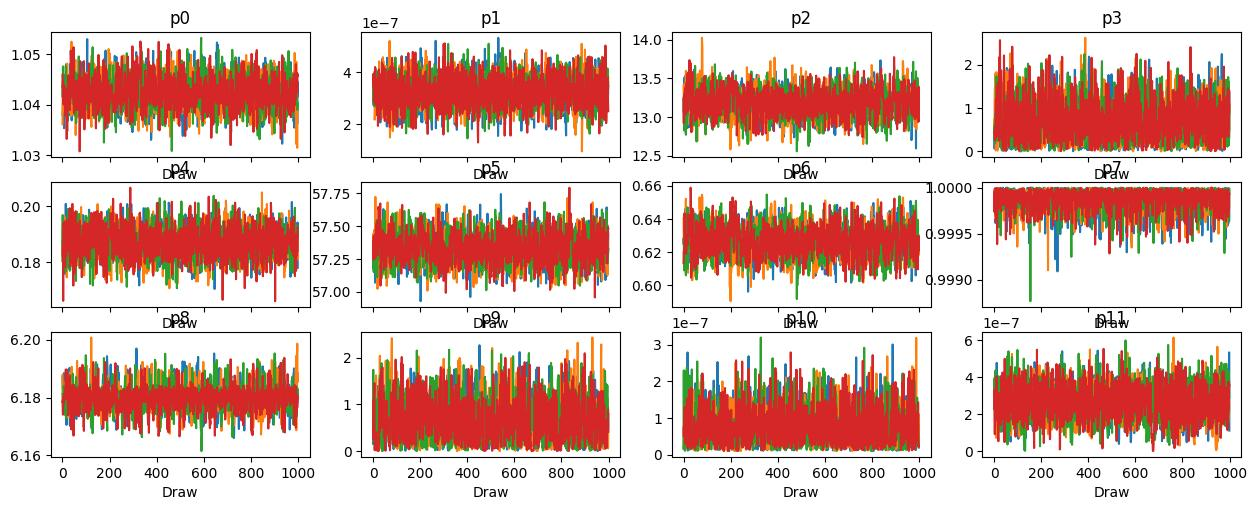

In [13]:
# The arviz package can display the traces for all the varying parameters.
# p0, p1, p2, ..., refer the the ordered list of varying parameters in the system.
az.plot_trace(idata, var_names=["p"], filter_vars="like");

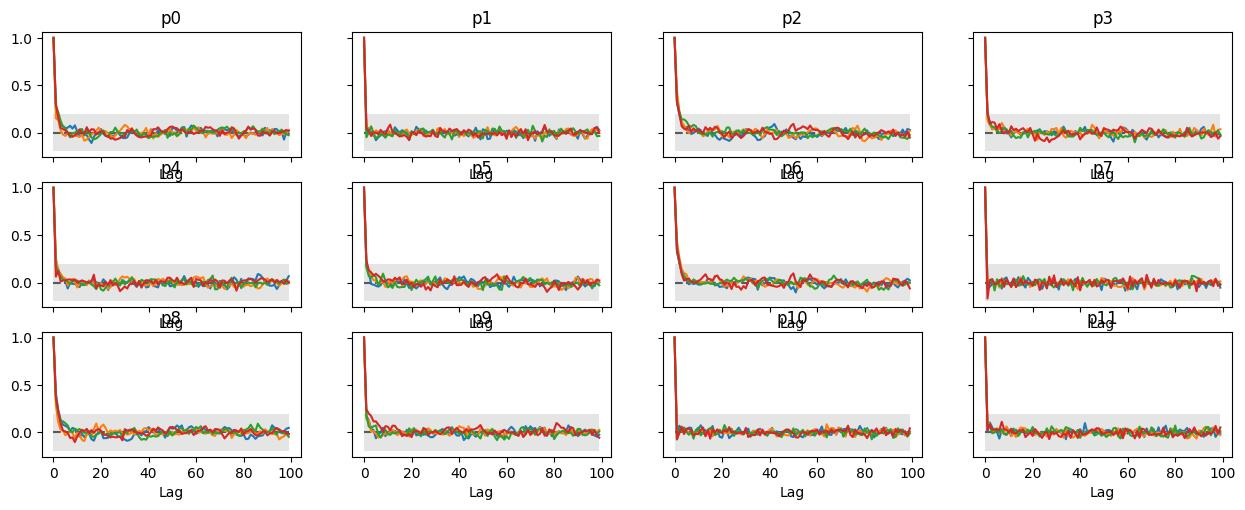

In [14]:
# arviz can plot the autocorrelation trace for each of the chains.
# Note how the autocorrelation time is low, which means that the draws are quite independent.
az.plot_autocorr(idata.posterior, var_names=["p"], filter_vars="like");

In [15]:
# Let's view the summary of the sampling
summary = az.summary(idata.posterior, var_names=["p"], filter_vars="like")
summary

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
p0,1.0424,0.0032,1,1,1900,2183,1.00,7.3e-05,5.4e-05
p1,3.25e-07,5.9e-08,2.3e-07,4.2e-07,3655,2571,1.00,9.8e-10,7.1e-10
p2,13.188,0.18,13,13,1374,1515,1.00,0.0049,0.0036
p3,0.66,0.48,0.061,1.5,1428,1323,1.00,0.011,0.0082
p4,0.1872,0.0054,0.18,0.2,2182,2405,1.00,0.00012,8.2e-05
p5,57.334,0.117,57,58,2141,2353,1.00,0.0025,0.0018
p6,0.6265,0.0093,0.61,0.64,1453,1904,1.00,0.00024,0.00017
p7,0.999883,0.000117,1,1,2464,1546,1.00,1.8e-06,2.5e-06
p8,6.1801,0.0045,6.2,6.2,1668,1260,1.00,0.00011,9.8e-05
p9,0.63,0.46,0.048,1.5,1506,1257,1.00,0.01,0.0074


In [16]:
# processing the trace associates the draws/samples back onto the various refnx objects.
process_trace(global_objective, idata);

In [17]:
print(global_objective.varying_parameters())
print(f"{float(tail_thickness) = }")
print(f"{float(head_thickness) = }")

________________________________________________________________________________
Parameters:      None      
<Parameter:    'scale'    , value=1.04237 +/- 0.00312, bounds=[0.9, 1.1]>
<Parameter:     'bkg'     , value=3.25292e-07 +/- 5.89e-08, bounds=[1e-08, 1e-06]>
<Parameter:'sio2 thickness', value=13.1882 +/- 0.178, bounds=[2.0, 30.0]>
<Parameter:'sio2 roughness', value=0.578851 +/- 0.502, bounds=[0.0, 7.0]>
<Parameter:'sio2 solvation', value=0.187141 +/- 0.00543, bounds=[0.0, 0.5]>
<Parameter:'area per molecule', value=57.3331 +/- 0.117, bounds=[52.0, 65.0]>
<Parameter:'volume fraction heads', value=0.626228 +/- 0.00915, bounds=[0.01, 1.0]>
<Parameter:'volume fraction tails', value=0.999919 +/- 9.77e-05, bounds=[0.01, 1.0]>
<Parameter:   'd2o SLD'   , value=6.18007 +/- 0.0038, bounds=[6.1, 6.36]>
<Parameter:'bilayer/solvent roughness', value=0.544894 +/- 0.484, bounds=[0.0, 5.0]>
<Parameter:     'bkg'     , value=6.1934e-08 +/- 4.82e-08, bounds=[1e-08, 1e-06]>
<Parameter:     'bkg' 

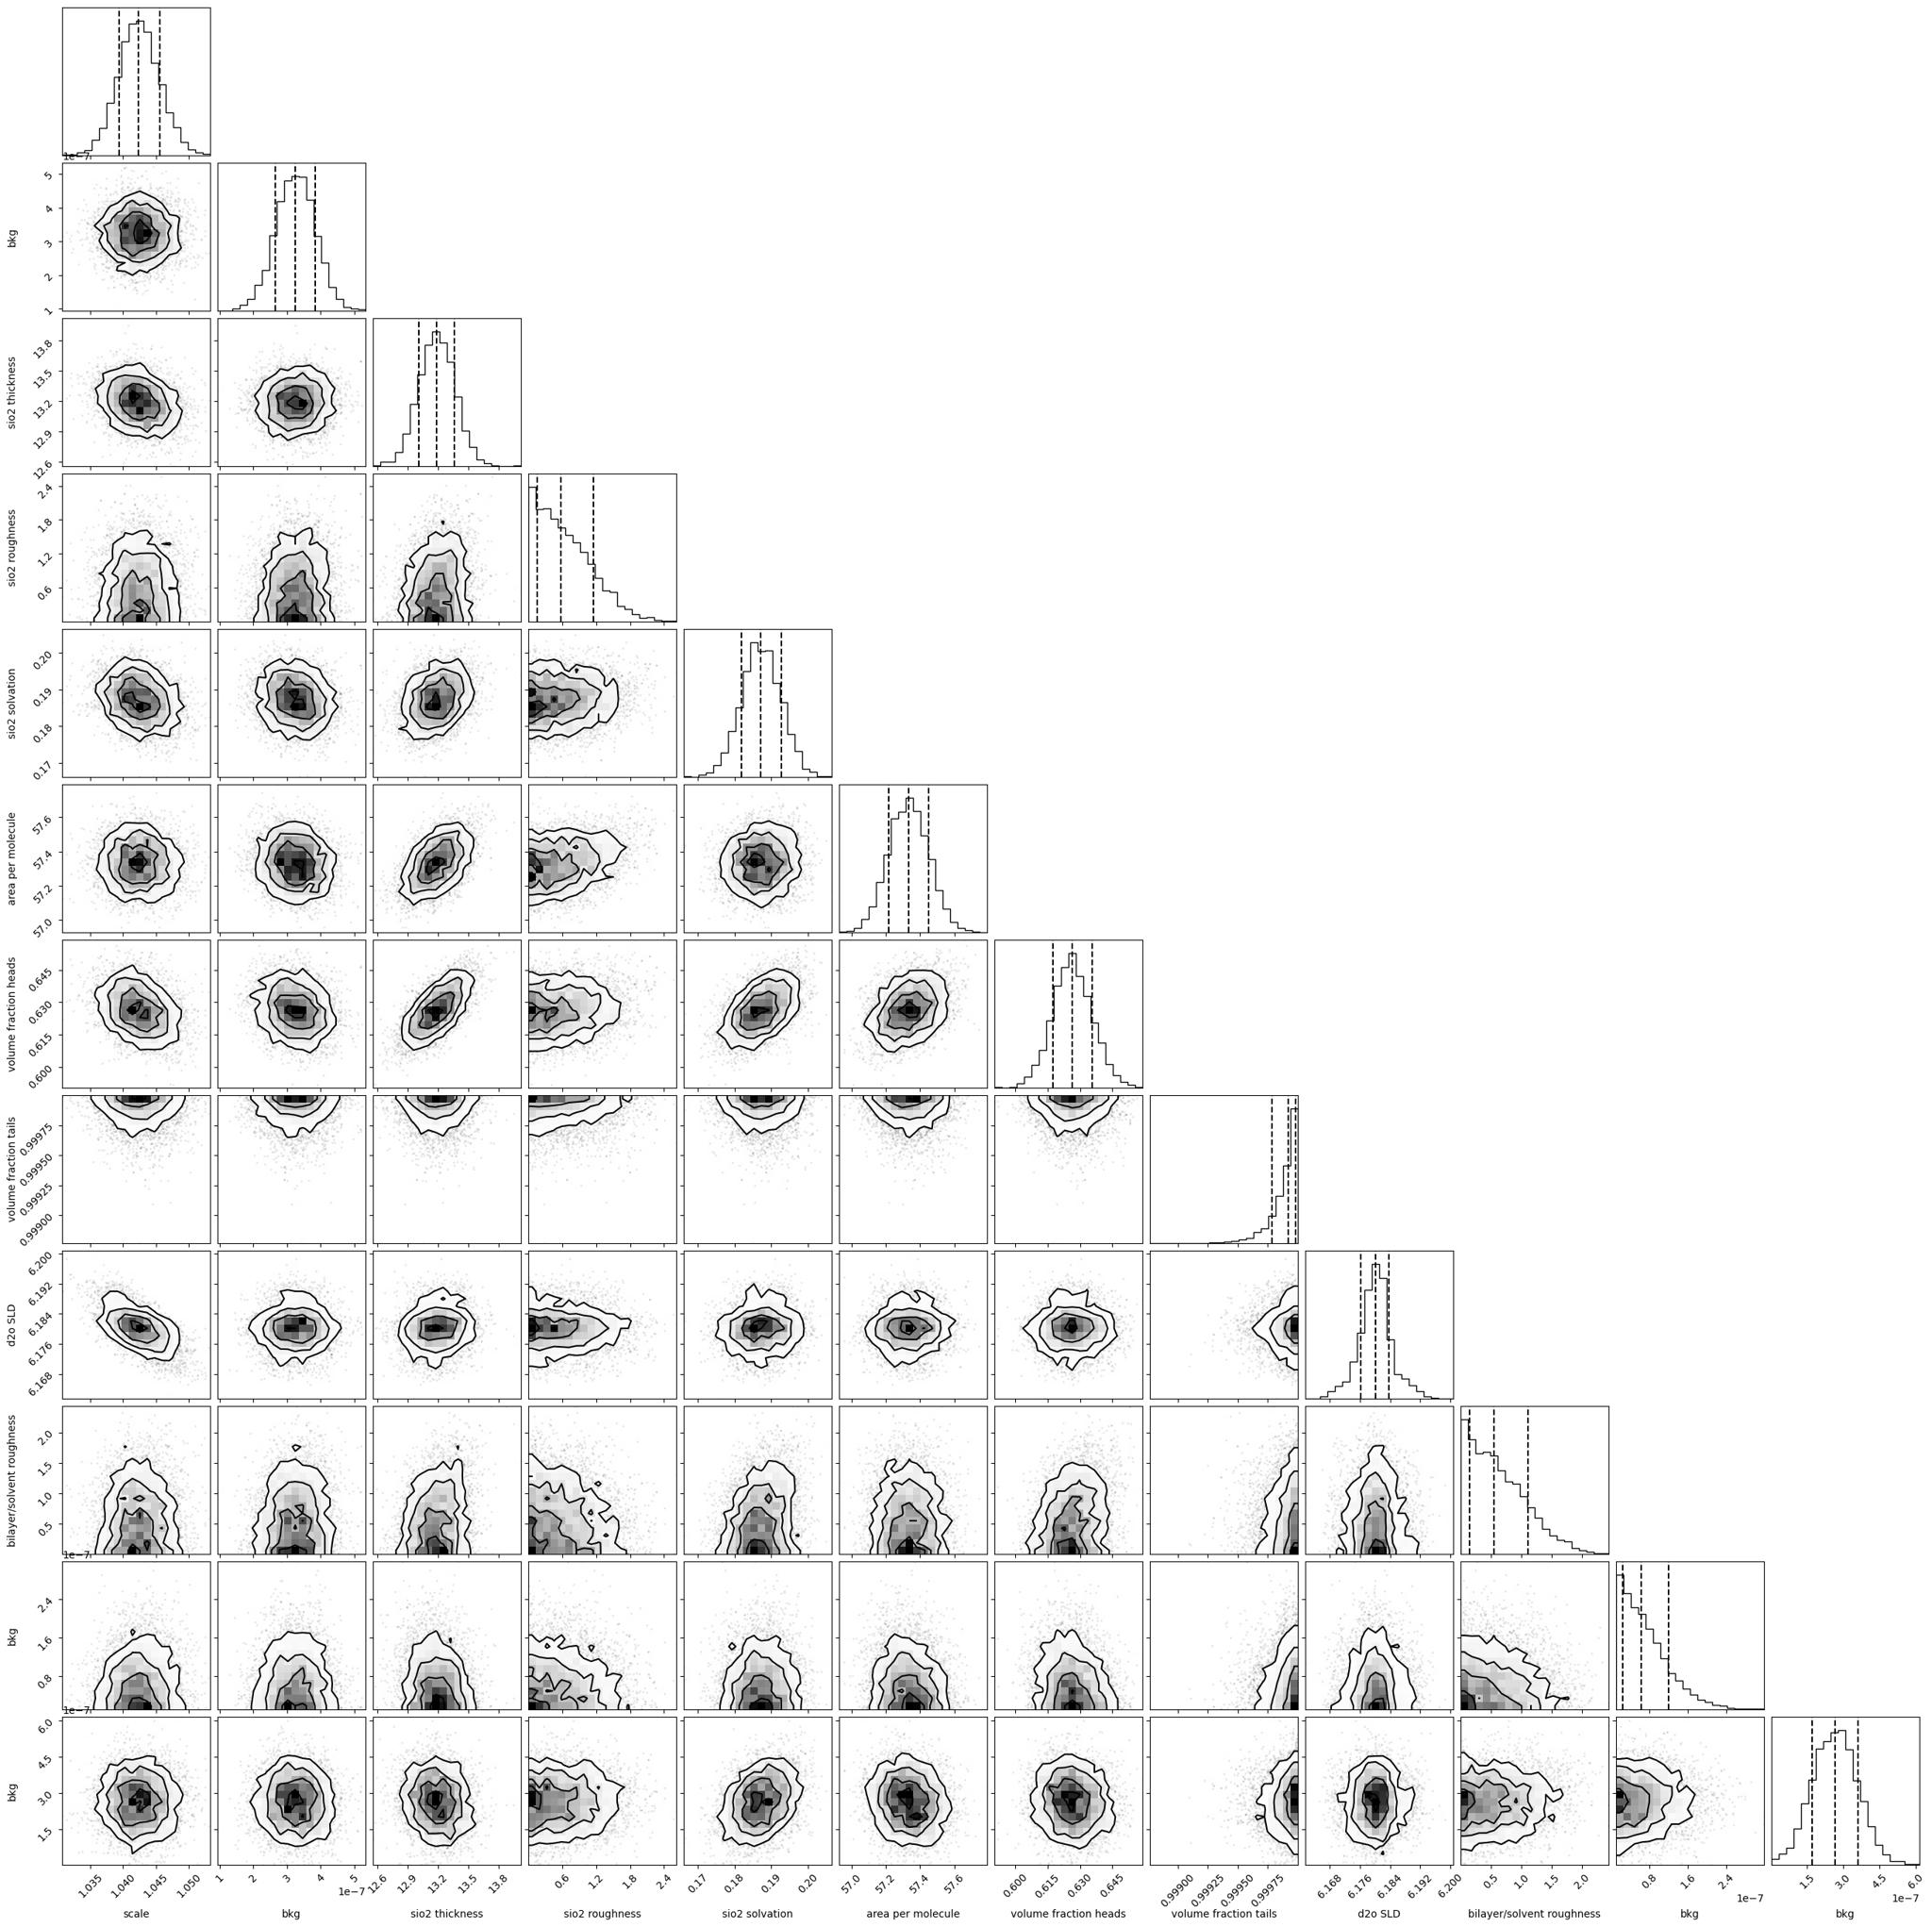

In [18]:
global_objective.corner();

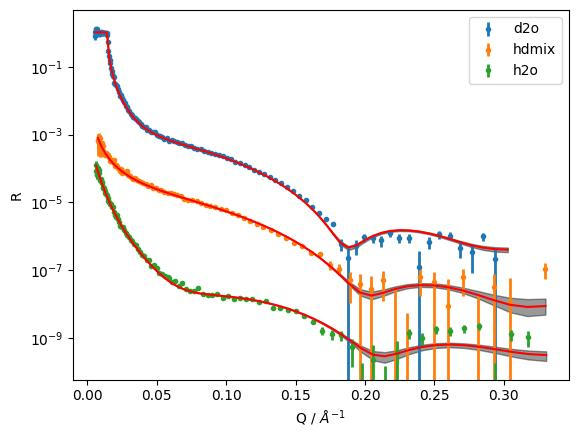

In [19]:
# v_offsets allows us to separate the traces vertically.
fig, ax = global_objective.plot(
    samples=True, sigma=1, v_offsets=(1.0, 0.1, 0.001)
)
ax.set_xlabel("Q / $\\AA^{-1}$")
ax.set_ylabel(r"R")

plt.yscale("log")
plt.legend();

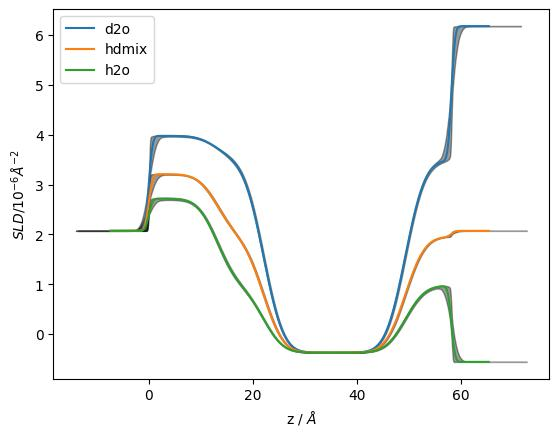

In [20]:
# access the same colours as the default matplotlib colour cycle.
colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

fig, ax = s_d2o.plot(samples=True, color=colors[0])
s_hdmix.plot(samples=True, fig=fig, color=colors[1])
s_h2o.plot(samples=True, fig=fig, color=colors[2])
plt.legend();